In [1]:
import pandas as pd
import numpy as np 
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
import os
print(os.getcwd())

/Users/ubah./Documents/MLDM ASSESSMENT/TASK 2/main task 2


In [3]:
#importing the dataset
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
print("Shape of dataset:", df.shape)


Shape of dataset: (13611, 17)


In [4]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [6]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [7]:
# Check for missing values
print("\n----- MISSING VALUES -----")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")



----- MISSING VALUES -----
No missing values found.


In [27]:
# Check for duplicate rows

duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [28]:
# Remove duplicate rows (if any)
df = df.drop_duplicates()


In [30]:
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [10]:
# List numeric columns for EDA
numeric_features = df.select_dtypes(include='number').columns
print("Numeric feature count:", len(numeric_features))
print("Numeric columns:", list(numeric_features))

Numeric feature count: 16
Numeric columns: ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


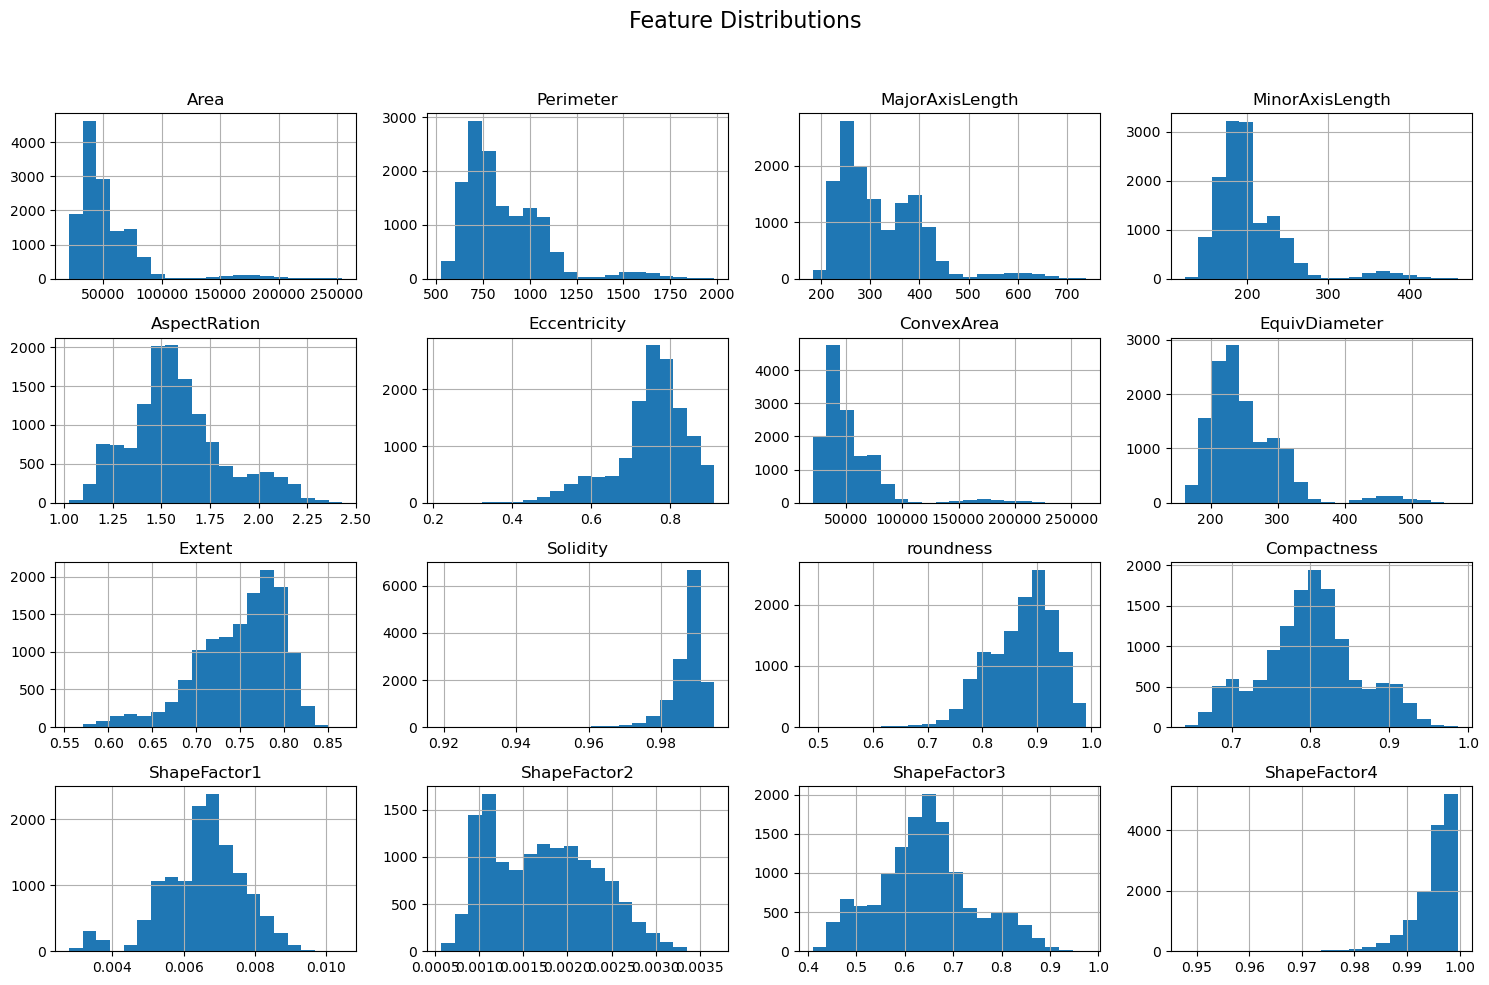

In [11]:
# Plot histograms to view distributions
import matplotlib.pyplot as plt
df[numeric_features].hist(bins=20, figsize=(15,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [12]:
# Feature preparation and scaling

from sklearn.preprocessing import StandardScaler
import numpy as np

# Separate features and labels
X = df.drop(columns=['Class']) 
y = df['Class']                 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)


In [13]:
# Display a preview
print("Scaled feature matrix shape:", X_scaled_df.shape)
display(X_scaled_df.head())

# Quick check of mean and standard deviation after scaling
means = np.round(X_scaled_df.mean(), 3)
stds = np.round(X_scaled_df.std(), 3)
print("\nFeature means (should be close to 0):")
display(means)
print("\nFeature stds (should be close to 1):")
display(stds)

Scaled feature matrix shape: (13543, 16)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,-0.838800,-1.139663,-1.301976,-0.632111,-1.565363,-2.182833,-0.839489,-1.060491,0.287981,0.366476,1.420346,1.838628,0.681918,2.398280,1.924811,0.838679
1,-0.827266,-1.010529,-1.391169,-0.435758,-1.972460,-3.685504,-0.824175,-1.041410,0.697598,-0.465886,0.224987,2.497622,0.369552,3.097471,2.691446,0.771141
2,-0.805287,-1.075303,-1.247807,-0.586775,-1.514305,-2.042229,-0.806818,-1.005357,0.577958,0.517614,1.248979,1.764053,0.604373,2.231086,1.840150,0.917418
3,-0.783920,-0.973894,-1.274241,-0.440595,-1.742960,-2.740196,-0.772170,-0.970686,0.671302,-2.248692,0.509588,2.082211,0.403254,2.511258,2.204306,-0.202373
4,-0.779429,-1.093821,-1.375750,-0.268281,-2.121534,-4.535823,-0.782457,-0.963445,0.475476,0.804605,1.872434,2.768598,0.120215,3.267675,3.016333,0.940406



Feature means (should be close to 0):


Area              -0.0
Perimeter          0.0
MajorAxisLength    0.0
MinorAxisLength   -0.0
AspectRation       0.0
Eccentricity      -0.0
ConvexArea         0.0
EquivDiameter     -0.0
Extent            -0.0
Solidity           0.0
roundness         -0.0
Compactness        0.0
ShapeFactor1       0.0
ShapeFactor2       0.0
ShapeFactor3       0.0
ShapeFactor4       0.0
dtype: float64


Feature stds (should be close to 1):


Area               1.0
Perimeter          1.0
MajorAxisLength    1.0
MinorAxisLength    1.0
AspectRation       1.0
Eccentricity       1.0
ConvexArea         1.0
EquivDiameter      1.0
Extent             1.0
Solidity           1.0
roundness          1.0
Compactness        1.0
ShapeFactor1       1.0
ShapeFactor2       1.0
ShapeFactor3       1.0
ShapeFactor4       1.0
dtype: float64

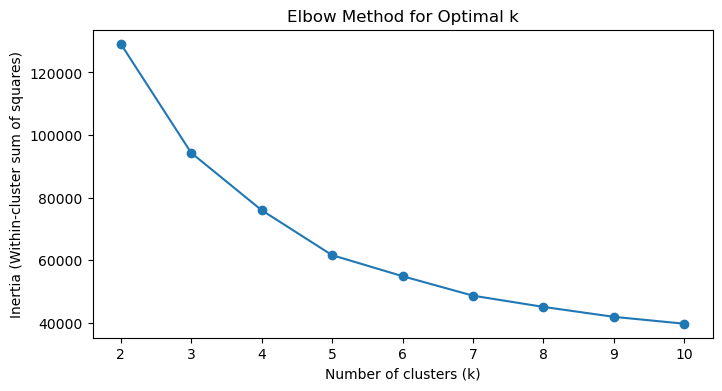

In [14]:
# Determine the optimal number of clusters for K-Means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
sil_scores = []
K = range(2, 11)  # test k from 2 to 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

# Plot the Elbow Method
plt.figure(figsize=(8,4))
plt.plot(K, inertias, 'o-')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-cluster sum of squares)")
plt.show()



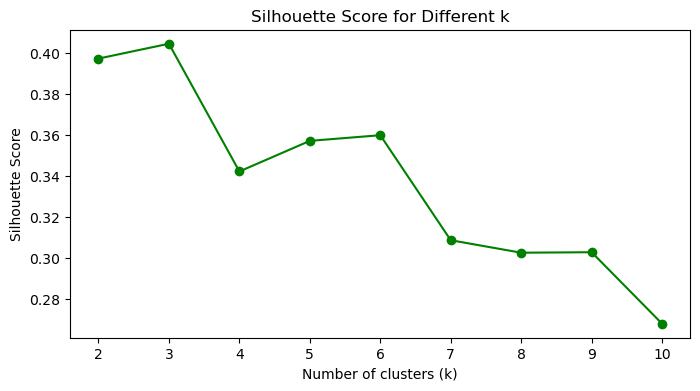

In [15]:
# Plot Silhouette Scores
plt.figure(figsize=(8,4))
plt.plot(K, sil_scores, 'o-', color='green')
plt.title("Silhouette Score for Different k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [16]:
# STEP 5B: Fit final K-Means model
k_final = 7  # (example — adjust based on your plots)
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
kmeans_final.fit(X_scaled)

# Predicted cluster labels
kmeans_labels = kmeans_final.labels_

# Add to DataFrame for inspection
df['KMeans_Cluster'] = kmeans_labels

# Cluster sizes
print("Cluster sizes:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# Quick preview
display(df[['Class', 'KMeans_Cluster']].head(10))

Cluster sizes:
KMeans_Cluster
0    3099
1    1706
2    2031
3     520
4    3174
5    2480
6     533
Name: count, dtype: int64


,Class,KMeans_Cluster
0,SEKER,2
1,SEKER,2
2,SEKER,2
3,SEKER,2
4,SEKER,2
5,SEKER,2
6,SEKER,2
7,SEKER,2
8,SEKER,2
9,SEKER,2


In [17]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(X_scaled, kmeans_labels)
db_score = davies_bouldin_score(X_scaled, kmeans_labels)

print(f"\nSilhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")


Silhouette Score: 0.309
Davies-Bouldin Index: 1.101


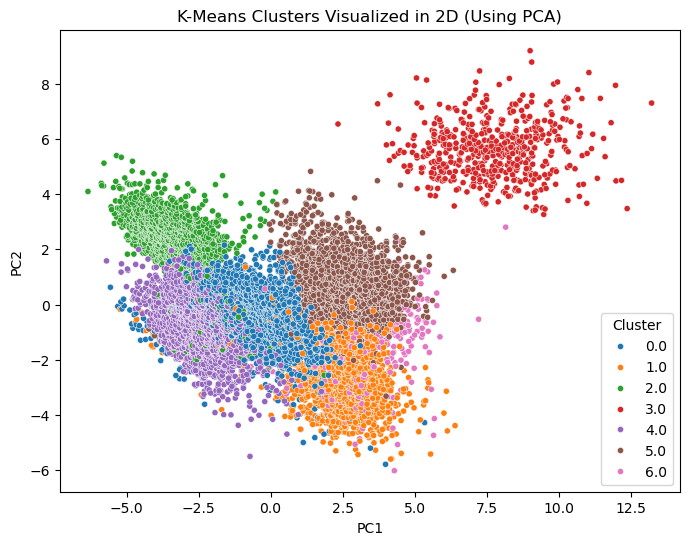

In [18]:
# Visualize K-Means Clusters using PCA (2 components)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce scaled data to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Add PCA results and cluster labels to a DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['KMeans_Cluster']

# Plot the clusters
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=20)
plt.title("K-Means Clusters Visualized in 2D (Using PCA)")
plt.show()

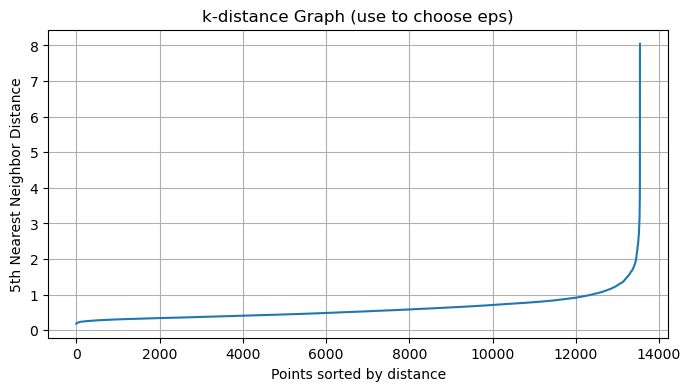

In [33]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Use scaled data
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Take the 5th nearest neighbor distances
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,4))
plt.plot(distances)
plt.title("k-distance Graph (use to choose eps)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.grid()
plt.show()

In [20]:
from sklearn.cluster import DBSCAN

eps_value = 1.1   # chosen from k-distance graph "elbow"
dbscan = DBSCAN(eps=eps_value, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_labels

print("Cluster label counts:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

Cluster label counts:
DBSCAN_Cluster
-1      495
 0    12591
 1        7
 2      427
 3        5
 4        4
 5        4
 6       10
Name: count, dtype: int64


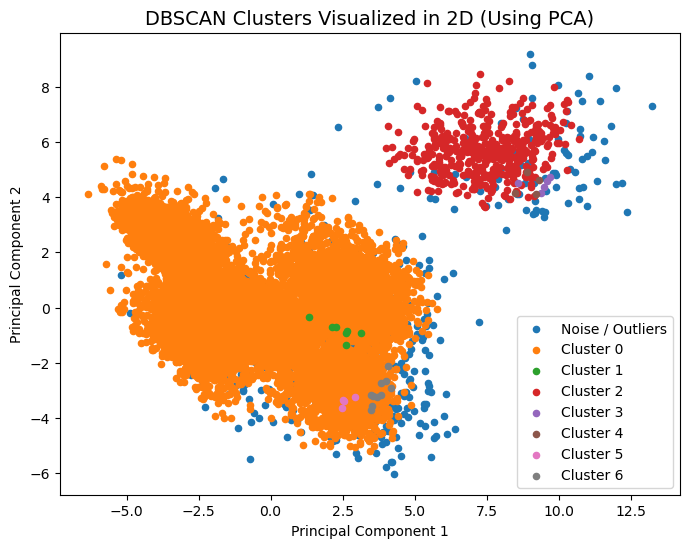

In [21]:
# Visualize DBSCAN Clusters using the same PCA components

plt.figure(figsize=(8,6))

# Loop through all unique cluster labels from DBSCAN
for cluster in sorted(set(db_labels)):
    
    # Label noise points (cluster = -1)
    if cluster == -1:
        label = "Noise / Outliers"
        color = 'black'
    else:
        label = f"Cluster {cluster}"
        color = None  # Lets matplotlib auto-assign colors
    
    # Draw the cluster points
    plt.scatter(
        X_pca[db_labels == cluster, 0],   # PC1
        X_pca[db_labels == cluster, 1],   # PC2
        s = 20,
        label = label
    )

plt.title("DBSCAN Clusters Visualized in 2D (Using PCA)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [22]:
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN_Cluster
-1      495
 0    12591
 1        7
 2      427
 3        5
 4        4
 5        4
 6       10
Name: count, dtype: int64
